We try to solve the heat equation.

$$
    \partial_t u - \Delta u = 0
$$

In [269]:
import numpy as np
import matplotlib.pyplot as plt
import pde
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import norm
from scipy.sparse.linalg import expm_multiply

In [4]:
def gaussian(x, mu, sigma):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.)))

In [591]:

T = 0.05
N_t = 20
dt = T / (N_t - 1)
t = np.arange(0, T, dt)

# Initial conditions
N = 6
dx = 1 / (N - 1)
L = 2
x = np.linspace(0, L, N)

u_0 = gaussian(x, 1, 0.2)
f_0 = np.fft.fft(u_0)

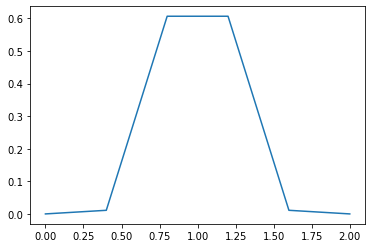

In [592]:
plt.plot(x, u_0)
plt.show()

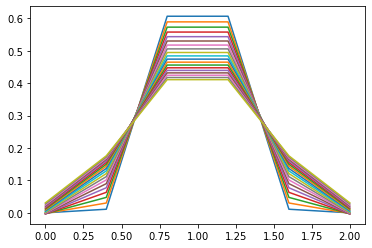

In [593]:
for t in np.arange(0, T, dt):
    # Solve the heat equation using the Fourier transform
    f_t = f_0 * np.exp(-t * np.fft.fftfreq(N, L / (N * 2 * np.pi))**2)
    u_t = np.fft.ifft(f_t)
    plt.plot(x, u_t.real)
plt.show()

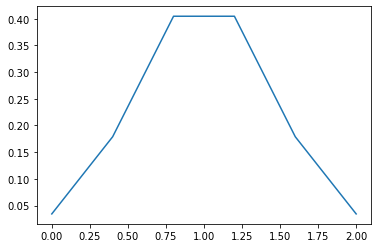

In [594]:

# Solve the heat equation using the Fourier transform
f_t = f_0 * np.exp(-T * np.fft.fftfreq(N, L / (N * 2 * np.pi))**2)
u_t = np.fft.ifft(f_t)
plt.plot(x, u_t.real)
plt.show()

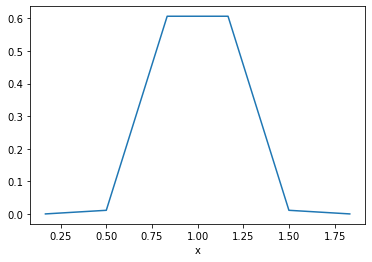

In [595]:
grid = pde.CartesianGrid([[0, L]], shape=[N], periodic=[True])               # generate grid
state = pde.ScalarField(grid, data=u_0) # generate initial condition
state.plot()
plt.show()

In [596]:
eq = pde.DiffusionPDE(diffusivity=1, bc="periodic")        # define the pde
result = eq.solve(state, t_range=T)

  0%|          | 0/0.05 [00:00<?, ?it/s]

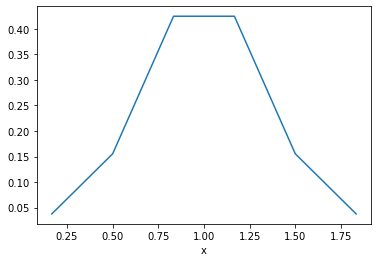

In [597]:
result.plot()
plt.show()

We apply the so-called Schrodingerization technique.

In [598]:
p = np.linspace(-L, L, N)

X, P = np.meshgrid(x, p, indexing='ij')

In [599]:
w = gaussian(X, 1, 0.2) * np.exp(-np.abs(P))

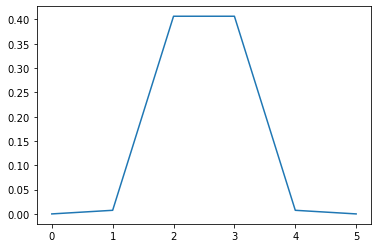

In [600]:
plt.plot(w[:,int(N/2)])
plt.show()

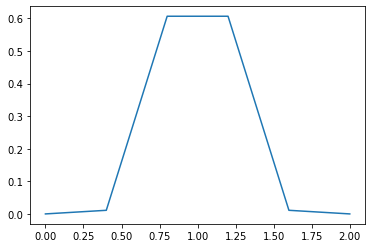

In [601]:
p_index = N-1
u_recover = np.exp(np.abs(p[p_index])) * w[:,p_index]

plt.plot(x, u_recover)
plt.show()

Setup the problem Hamiltonian

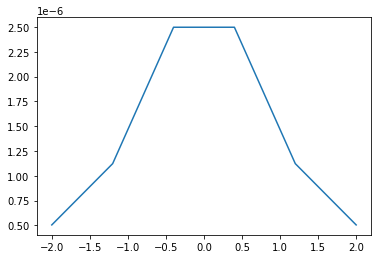

In [602]:
w_flatten = w.flatten()
plt.plot(p, w_flatten[0:N])
plt.show()

In [603]:
dx = L / (N - 1)
dp = 2 * L / (N - 1)

In [604]:
H = lil_matrix((N * N, N * N), dtype=np.complex64)
for i in range(N):
    for j in range(N):
        index = N * i + j


        # (i+1,j)
        # index_m = N * ((i + 1) % N) + j
        # H[index, index_m] = - 0.5j / dx
        # H[index_m, index] = 0.5j / dx

        # (i,j-1) and (i,j+1)
        index_m = N * i + ((j - 1) % N)
        H[index, index_m] = - 2j / (2 * dp * dx ** 2)
        H[index_m, index] = 2j / (2 * dp * dx ** 2)

        # index_p = N * i + ((j + 1) % N)
        # H[index, index_p] = 2 * 1j / (2 * dp * dx ** 2)
        # H[index_p, index] = - 2 * 1j / (2 * dp * dx ** 2)
        
        # (i-1,j+1) and (i+1,j-1)
        index_m = N * ((i - 1) % N) + ((j + 1) % N)
        H[index, index_m] = - 1j / (2 * dp * dx ** 2)
        H[index_m, index] = 1j / (2 * dp * dx ** 2)
        
        # index_p = N * ((i + 1) % N) + ((j - 1) % N)
        # H[index, index_p] = 1j / (2 * dp * dx ** 2)
        # H[index_p, index] = - 1j / (2 * dp * dx ** 2)

        # (i+1,j+1) and (i-1,j-1)
        index_m = N * ((i + 1) % N) + ((j + 1) % N)
        H[index, index_m] = - 1j / (2 * dp * dx ** 2)
        H[index_m, index] = 1j / (2 * dp * dx ** 2)

        # index_p = N * ((i - 1) % N) + ((j - 1) % N)
        # H[index, index_p] = 1j / (2 * dp * dx ** 2)
        # H[index_p, index] = - 1j / (2 * dp * dx ** 2)

In [605]:
H = lil_matrix((N * N, N * N), dtype=np.complex64)
for i in range(N):
    for j in range(N):
        index = N * i + j


        # (i+1,j)
        # index_m = N * ((i + 1) % N) + j
        # H[index, index_m] = - 0.5j / dx
        # H[index_m, index] = 0.5j / dx

        # (i,j-1) and (i,j+1)
        index_m = N * i + ((j - 1) % N)
        H[index, index_m] = - 2j / (dp * dx ** 2)
        H[index_m, index] = 2j / (dp * dx ** 2)

        # index_p = N * i + ((j + 1) % N)
        # H[index, index_p] = 2 * 1j / (2 * dp * dx ** 2)
        # H[index_p, index] = - 2 * 1j / (2 * dp * dx ** 2)
        
        # (i-1,j+1) and (i+1,j-1)
        index_m = N * ((i - 1) % N) + ((j + 1) % N)
        H[index, index_m] = - 1j / (dp * dx ** 2)
        H[index_m, index] = 1j / (dp * dx ** 2)
        
        # index_p = N * ((i + 1) % N) + ((j - 1) % N)
        # H[index, index_p] = 1j / (2 * dp * dx ** 2)
        # H[index_p, index] = - 1j / (2 * dp * dx ** 2)

        # (i+1,j+1) and (i-1,j-1)
        index_m = N * ((i + 1) % N) + ((j + 1) % N)
        H[index, index_m] = - 1j / (dp * dx ** 2)
        H[index_m, index] = 1j / (dp * dx ** 2)

        # index_p = N * ((i - 1) % N) + ((j - 1) % N)
        # H[index, index_p] = 1j / (2 * dp * dx ** 2)
        # H[index_p, index] = - 1j / (2 * dp * dx ** 2)

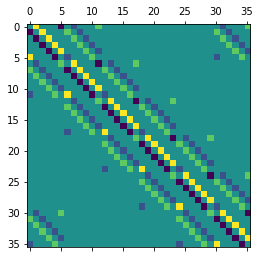

In [606]:
plt.matshow(H.toarray().imag)
plt.show()

In [607]:
from utils import *

def sum_J_yz(n : int, J : np.ndarray) -> np.ndarray:
    # row of J is for Pauli Z, column is for Pauli Y
    # J_{i,j} is coefficient of Y_i Z_j
    assert n > 0
    assert J.shape == (n,n)

    dims = [2 ** i for i in range(n)]

    res = csc_matrix((2 ** n, 2 ** n))
    for i in range(n):
        for j in range(i):
            res += J[i,j] * tensor([identity(dims[n-i-1], format='csr'), PAULI_Y, identity(dims[i-j-1], format='csr'), PAULI_Z, identity(dims[j], format='csr')])
            
    for j in range(n):
        for i in range(j):
            res += J[i,j] * tensor([identity(dims[n-j-1], format='csr'), PAULI_Z, identity(dims[j-i-1], format='csr'), PAULI_Y, identity(dims[i], format='csr')])
            
    return res

def sum_J_xy(n : int, J : np.ndarray) -> np.ndarray:
    # row of J is for Pauli Z, column is for Pauli Y
    # J_{i,j} is coefficient of X_i Y_j
    assert n > 0
    assert J.shape == (n,n)

    dims = [2 ** i for i in range(n)]

    res = csc_matrix((2 ** n, 2 ** n))
    for i in range(n):
        for j in range(i):
            res += J[i,j] * tensor([identity(dims[n-i-1], format='csr'), PAULI_X, identity(dims[i-j-1], format='csr'), PAULI_Y, identity(dims[j], format='csr')])
            
    for j in range(n):
        for i in range(j):
            res += J[i,j] * tensor([identity(dims[n-j-1], format='csr'), PAULI_Y, identity(dims[j-i-1], format='csr'), PAULI_X, identity(dims[i], format='csr')])
            
    return res

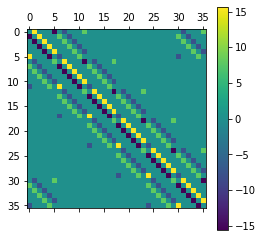

In [621]:
plt.matshow(H.toarray().imag)
plt.colorbar()
plt.show()

In [622]:
# Returns the codewords using unary embedding
def get_codewords_1d_unary(n : int, periodic):
    
    codewords = []

    bitstring = [0 for k in range(n)]

    if periodic:
        for i in range(2 * n):

            codewords.append(np.copy(bitstring))

            bitstring[i % n] = 1 - bitstring[i % n]

    else:
        for i in range(n+1):

            codewords.append(np.copy(bitstring))

            if i < n:
                bitstring[i] = 1 - bitstring[i]
    return codewords

def get_codewords_2d_unary(n : int, periodic):
    C_1d = get_codewords_1d_unary(n, periodic)
    
    C = []
    for i in range(len(C_1d)):
        for j in range(len(C_1d)):
            C.append(np.concatenate([C_1d[i], C_1d[j]]))
    return C

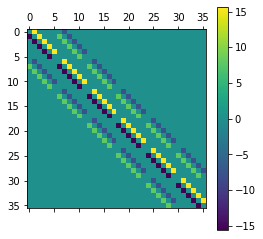

: 

In [625]:
periodic = False

if periodic:
    n = int(N / 2)
else:
    n = N - 1

J = np.zeros((2 * n, 2 * n))
J[2 * n-1,n] = 1
for i in range(n, 2 * n-1):
    J[i,i+1] = -1

H_full = 2 * sum_J_yz(2 * n, J) / (dp * dx ** 2)

J = np.zeros((2 * n, 2 * n))

for i in range(0, n):
    for j in range(n, 2 * n):
        J[i,j] = 1
H_full += sum_J_xy(2 * n, J) / (dp * dx ** 2)

C = get_codewords_2d_unary(n, periodic=periodic)

H_subspace = np.zeros((N ** 2, N ** 2), dtype=np.complex64)

for i in range(N ** 2):
    index_1 = bitstring_to_int(C[i])

    for j in range(N ** 2):
        index_2 = bitstring_to_int(C[j])
        H_subspace[i,j] = H_full[index_1, index_2]

plt.matshow(H_subspace.imag)
plt.colorbar()
plt.show()

In [584]:
# w = expm_multiply(-1j * H * T, w_flatten).reshape(N, N).real

In [585]:


# p_index = 5
# u_recover = np.exp(np.abs(p[p_index])) * w[:,p_index]

# plt.plot(x, u_recover)
# plt.show()